<a href="https://colab.research.google.com/github/Parigarg2006/currency-converter-live-rates-python/blob/main/currency_converter_live_rates_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

currency-converter-live-rates-python

✅ Rates loaded (base: USD) | Updated: Fri, 08 May 2026 00:02:31 +0000

₹1000 = $10.5985  (rate: 0.010599)

💱 100 USD =
----------------------------------------
  INR       9435.2906   (1 USD = 94.3529 INR)
  EUR         85.1418   (1 USD = 0.8514 EUR)
  GBP         73.5903   (1 USD = 0.7359 GBP)
  JPY      15661.1257   (1 USD = 156.6113 JPY)
  AED        367.2500   (1 USD = 3.6725 AED)
  SGD        126.7841   (1 USD = 1.2678 SGD)

📋 Conversion History
Time             From     To       Amount         Result
-------------------------------------------------------
11:43:47      1000.00 INR → USD           10.5985
11:43:47       100.00 USD → INR         9435.2906
11:43:47       100.00 USD → EUR           85.1418
11:43:47       100.00 USD → GBP           73.5903
11:43:47       100.00 USD → JPY        15661.1257
11:43:47       100.00 USD → AED          367.2500
11:43:47       100.00 USD → SGD          126.7841


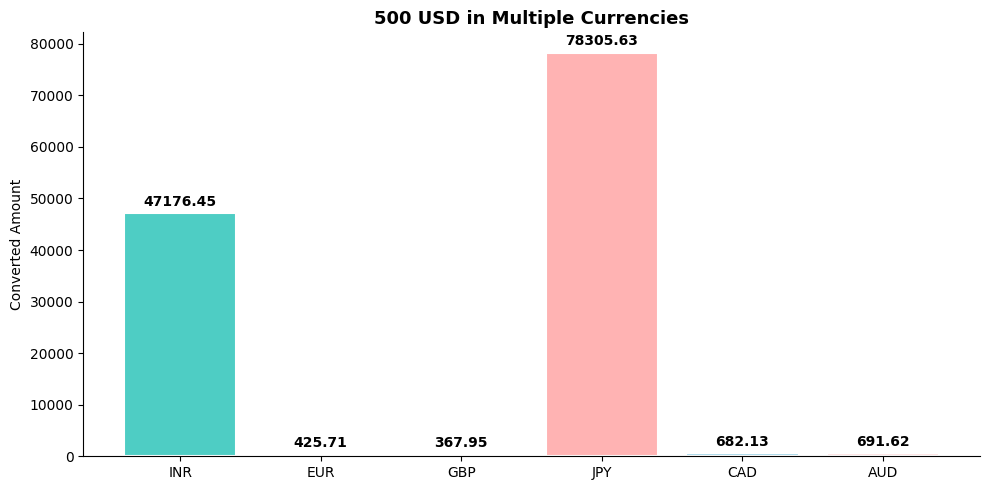

📊 Chart saved as currency_chart.png


In [1]:
# pip install requests matplotlib pandas
import requests
import json
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------------------------------
# FREE API: https://open.er-api.com/v6/latest/USD (no key needed)
# -----------------------------------------------------------

BASE_URL = "https://open.er-api.com/v6/latest"

class CurrencyConverter:
    def __init__(self):
        self.rates = {}
        self.base = "USD"
        self.history = []
        self.fetch_rates()

    def fetch_rates(self, base="USD"):
        try:
            response = requests.get(f"{BASE_URL}/{base}", timeout=5)
            data = response.json()
            if data.get("result") == "success":
                self.rates = data["rates"]
                self.base = base
                self.last_updated = data.get("time_last_update_utc", "Unknown")
                print(f"✅ Rates loaded (base: {base}) | Updated: {self.last_updated}")
            else:
                raise Exception("API error")
        except Exception as e:
            print(f"⚠️  Using offline fallback rates. ({e})")
            self.rates = {
                "USD": 1.0, "INR": 83.5, "EUR": 0.92, "GBP": 0.79,
                "JPY": 149.5, "CAD": 1.36, "AUD": 1.53, "CHF": 0.89,
                "CNY": 7.24, "SGD": 1.34, "AED": 3.67, "SAR": 3.75,
            }
            self.last_updated = "Offline"

    def convert(self, amount, from_cur, to_cur):
        from_cur, to_cur = from_cur.upper(), to_cur.upper()
        if from_cur not in self.rates or to_cur not in self.rates:
            print(f"❌ Unknown currency: {from_cur} or {to_cur}")
            return None
        # Convert via USD as base
        in_usd = amount / self.rates[from_cur]
        result = in_usd * self.rates[to_cur]
        rate = self.rates[to_cur] / self.rates[from_cur]
        self.history.append({
            "time": datetime.now().strftime("%H:%M:%S"),
            "from": from_cur, "to": to_cur,
            "amount": amount, "result": result, "rate": rate
        })
        return result, rate

    def multi_convert(self, amount, from_cur, targets):
        print(f"\n💱 {amount} {from_cur.upper()} =")
        print("-" * 40)
        for cur in targets:
            out = self.convert(amount, from_cur, cur)
            if out:
                result, rate = out
                print(f"  {cur.upper():<6} {result:>12.4f}   (1 {from_cur.upper()} = {rate:.4f} {cur.upper()})")

    def show_history(self):
        if not self.history:
            print("No conversions yet.")
            return
        print("\n📋 Conversion History")
        print(f"{'Time':<12} {'From':>8} {'To':>6} {'Amount':>12} {'Result':>14}")
        print("-" * 55)
        for h in self.history[-10:]:
            print(f"{h['time']:<12} {h['amount']:>8.2f} {h['from']} → {h['to']:<6} {h['result']:>14.4f}")

    def plot_comparison(self, amount, from_cur, currencies):
        results = {}
        for cur in currencies:
            out = self.convert(amount, from_cur, cur)
            if out:
                results[cur] = out[0]

        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['#4ECDC4', '#FF6B6B', '#95E1D3', '#FFB3B3', '#A8D8EA', '#FEE2E2']
        bars = ax.bar(results.keys(), results.values(),
                      color=colors[:len(results)], edgecolor='white', linewidth=1.5)
        for bar, (cur, val) in zip(bars, results.items()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(results.values())*0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_title(f'{amount} {from_cur.upper()} in Multiple Currencies', fontsize=13, fontweight='bold')
        ax.set_ylabel('Converted Amount')
        ax.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.savefig('currency_chart.png', dpi=150)
        plt.show()
        print("📊 Chart saved as currency_chart.png")


# ---- Run it ----
cc = CurrencyConverter()

# Single conversion
result, rate = cc.convert(1000, "INR", "USD")
print(f"\n₹1000 = ${result:.4f}  (rate: {rate:.6f})")

# Multi conversion
cc.multi_convert(100, "USD", ["INR", "EUR", "GBP", "JPY", "AED", "SGD"])

# History
cc.show_history()

# Chart comparison
cc.plot_comparison(500, "USD", ["INR", "EUR", "GBP", "JPY", "CAD", "AUD"])